# Principal Component Analysis (PCA)

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement PCA for dimensionality reduction
- Interpret explained variance and components
- Use PCA for visualization and preprocessing

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 06 "Developing Simple Supervised and Unsupervised Learning Models" — you clustered iris in four dimensions there without being able to see it; PCA is how you get it onto a page.

**Used later in:** Course 04 (AIAT 114) — Unit 4, lesson 03 "Principal Component Analysis (PCA)" — where you call `PCA()` instead of building it.

---


---

## 📌 Real case: a map of Europe fell out of a covariance matrix

In 2008, John Novembre and colleagues published **"Genes mirror geography within Europe"** in *Nature*
(456, 98–101). They took **1,387 European individuals** genotyped at **197,146 SNP loci**, ran the
procedure in this notebook — centre the data, take the top two principal components — and plotted each
person as a point. The result reproduced a recognisable **map of Europe**: the Iberian peninsula, the
Italian peninsula, south-eastern Europe, Cyprus and Turkey all appear in their correct relative positions.
Nothing in the analysis was told where anybody came from. In their words, "a geographical map of Europe
arises naturally as an efficient two-dimensional summary of genetic variation in Europeans," and roughly
half of the individuals could be placed within 310 km of their reported origin.

That is PCA doing exactly what the cells below do, at 197,146 features instead of 30.

**What goes wrong without this.** With 197,146 columns you cannot plot the data, you cannot eyeball it, and
almost any model you fit will memorise. Two numbers per person made a continent's population history
visible. The same move below turns 30 tumour measurements into a picture in which two diagnoses separate —
and the notebook is careful to note that **PCA never saw the diagnosis label**.


# Principal Component Analysis (PCA)

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Module 01: Linear Algebra** - Understand eigenvalues and eigenvectors
- ✅ **Module 03: Optimization** - Understand optimization concepts
- ✅ **Basic understanding**: What is dimensionality reduction?

**If you haven't completed these**, you might struggle with:
- Understanding PCA algorithm
- Understanding eigenvalue decomposition
- Applying PCA to data

---

## 🔗 Where This Notebook Fits

**This is the FIRST example of Module 04** - reducing dimensions!

**Why this example FIRST?**
- **Before** you can reduce dimensions, you need PCA
- **Before** you can understand other techniques, you need PCA foundation
- **Before** you can handle high-dimensional data, you need dimensionality reduction

**Builds on**: Module 01 (eigenvalues), Module 03 (optimization)

**Leads to**: Example 2: Curse of Dimensionality, Example 3: Feature Selection

---

## The Story: Understanding Before Using

Imagine you have a 1000-page book but only need the key points. **Before** you can summarize, you need to find the most important pages. **After** understanding PCA, you can reduce data dimensions while keeping the most important information!

Same with machine learning: **Before** handling high-dimensional data, we struggle with complexity. **After** understanding PCA, we can reduce dimensions while preserving information!

---

## Why This Concept Matters

### Why PCA Matters in ML

**WHY** is PCA essential?

1. **Dimensionality Reduction**:
   - **WHY**: High-dimensional data is hard to work with
   - **HOW**: PCA finds directions of maximum variance
   - **AFTER**: Simpler, more manageable data

2. **Data Compression**:
   - **WHY**: Reduce storage and computation
   - **HOW**: Keep only important components
   - **AFTER**: Faster training and inference

3. **Visualization**:
   - **WHY**: Can't visualize high-dimensional data
   - **HOW**: Project to 2D/3D using PCA
   - **AFTER**: Can visualize and understand data

**Common Student Questions:**
- **Q: What is PCA?**
  - Answer: PCA = Principal Component Analysis = finds directions of maximum variance
  - Problem: High-dimensional data (many features) is hard to work with
  - Solution: PCA finds new axes (principal components) that capture most information
  - Result: Reduced dimensions while keeping most information
- **Q: Why use PCA?**
  - Answer: Reduces dimensions → faster training, less storage, easier visualization
  - Problem: 1000 features → slow training, hard to visualize
  - Solution: PCA reduces to 10-50 components → much faster, can visualize
  - Trade-off: Some information lost, but usually minimal
- **Q: What is explained variance?**
  - Answer: Explained variance = how much information each component captures
  - Example: First component captures 40% variance, second captures 20% → together = 60%
  - Rule of thumb: Keep components that explain 80-95% of variance
  - More components = more information kept, but more dimensions
- **Q: How many components should I keep?**
  - Answer: Keep enough to explain 80-95% of variance
  - Too few: Lose important information
  - Too many: Don't reduce dimensions much
  - Use elbow method: Plot explained variance → find where curve flattens
  - Example: 10 components explain 90% → keep 10 (good balance)
- **Q: Does PCA lose information?**
  - Answer: Yes, but usually minimal if done correctly
  - PCA keeps directions of maximum variance → discards less important directions
  - If 95% variance explained → only 5% information lost
  - Trade-off: Small information loss for huge dimension reduction
  - In practice: Often improves model performance (removes noise)

## Learning Objectives
1. Understand PCA algorithm
2. Apply PCA to reduce dimensions
3. Understand explained variance
4. Visualize PCA results
5. Apply to real ML scenarios

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib for the maths and plots, plus sklearn for PCA, scaling,
# and the real breast-cancer dataset we run PCA on.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

print('✅ Libraries imported successfully!')


✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this works in ML!

## Step 2: Implementation

**BEFORE**: We understand the concept.

**AFTER**: We'll see HOW it's implemented!

In [2]:
# Example 1: PCA Implementation on REAL data
# WHY: Reduce dimensions while keeping information
# HOW: Find eigenvectors of covariance matrix (Module 01!)

# Real dataset: Wisconsin Breast Cancer diagnostic study - 569 tumour biopsies with
# 30 measurements each (radius, texture, perimeter, area, smoothness, ... , plus their
# standard-error and "worst" variants). Many of these are genuinely correlated:
# a bigger radius means a bigger perimeter and a bigger area. That real redundancy is
# what PCA compresses - we do not have to invent it.
cancer = load_breast_cancer()
data = cancer.data
labels = cancer.target  # 0 = malignant, 1 = benign

# Standardize data (essential here: 'mean area' is in the hundreds while
# 'mean smoothness' is around 0.1 - without scaling PCA would just track the units)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Apply PCA
pca = PCA(n_components=3)
data_reduced = pca.fit_transform(data_scaled)

print("Example 1: PCA Implementation")
print("=" * 60)
print(f"Dataset: {cancer.data.shape[0]} biopsies x {cancer.data.shape[1]} measurements")
print(f"Original data shape: {data.shape}")
print(f"Reduced data shape: {data_reduced.shape}")
print(f"\nExplained variance ratios: {pca.explained_variance_ratio_.round(4)}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")
print(f"\n💡 WHY: Reduced from {data.shape[1]}D to {data_reduced.shape[1]}D")
print(f"💡 HOW: Found directions of maximum variance (eigenvectors)")
print(f"💡 AFTER: Preserved {pca.explained_variance_ratio_.sum():.1%} of the variance!")

# Honest scaling check: how many components would the usual 80-95% rule really need?
full = PCA().fit(data_scaled)
cum = np.cumsum(full.explained_variance_ratio_)
for target in (0.80, 0.95):
    k = int(np.argmax(cum >= target) + 1)
    print(f"   To keep {target:.0%} of the variance you need {k} of the {data.shape[1]} components.")
print("   Real data is messier than a textbook example - 3 components is a compression,")
print("   not a free lunch.")


Example 1: PCA Implementation
Dataset: 569 biopsies x 30 measurements
Original data shape: (569, 30)
Reduced data shape: (569, 3)

Explained variance ratios: [0.4427 0.1897 0.0939]
Total variance explained: 72.6%

💡 WHY: Reduced from 30D to 3D
💡 HOW: Found directions of maximum variance (eigenvectors)
💡 AFTER: Preserved 72.6% of the variance!
   To keep 80% of the variance you need 5 of the 30 components.
   To keep 95% of the variance you need 10 of the 30 components.
   Real data is messier than a textbook example - 3 components is a compression,
   not a free lunch.


### 🧪 How many components should you actually keep?

"Explained variance" answers a question about the data. The question you usually care about is a question
about a *task*. Baseline: train a classifier on all 30 standardized measurements. Change one thing: replace
them with the top k principal components, for several k. Measure: cross-validated accuracy — the number a
hospital would actually ask about.

In [3]:
# Comparative experiment: variance explained vs downstream accuracy, on the same 569 biopsies.
# Every model below is scored with the SAME 5-fold cross-validation, so the only thing that
# changes between rows is how many principal components the classifier is allowed to see.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

y = cancer.target                       # the real diagnoses (0 = malignant, 1 = benign)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

print(f"{'components':>11} {'variance kept':>15} {'5-fold accuracy':>17}")
print("-" * 46)
for k in [1, 2, 3, 5, 10, 20, 30]:
    # PCA sits INSIDE the pipeline, so it is refitted on each training fold - no test data
    # leaks into the components. (The demonstration cells above fit PCA on all the rows.)
    pipe = make_pipeline(StandardScaler(), PCA(n_components=k),
                         LogisticRegression(max_iter=5000))
    acc = cross_val_score(pipe, cancer.data, y, cv=cv).mean()
    kept = PCA(n_components=k).fit(StandardScaler().fit_transform(cancer.data)) \
             .explained_variance_ratio_.sum()
    print(f"{k:>11} {100 * kept:>14.1f}% {acc:>16.4f}")

baseline = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
                           cancer.data, y, cv=cv).mean()
print("-" * 46)
print(f"{'all 30 raw':>11} {100.0:>14.1f}% {baseline:>16.4f}   <- no PCA at all")
print()
print("Conclusion the numbers support: read the two columns against each other. Variance kept and")
print("accuracy do NOT rise together - accuracy climbs steeply over the first few components and")
print("then flattens long before the variance does. Choosing k by 'keep 95% of the variance' is a")
print("rule about the data; choosing it by this table is a decision about the job. When you have")
print("labels, measure the thing you care about.")

 components   variance kept   5-fold accuracy
----------------------------------------------
          1           44.3%           0.9121
          2           63.2%           0.9578
          3           72.6%           0.9491
          5           84.7%           0.9736
         10           95.2%           0.9807
         20           99.6%           0.9772
         30          100.0%           0.9789
----------------------------------------------
 all 30 raw          100.0%           0.9789   <- no PCA at all

Conclusion the numbers support: read the two columns against each other. Variance kept and
accuracy do NOT rise together - accuracy climbs steeply over the first few components and
then flattens long before the variance does. Choosing k by 'keep 95% of the variance' is a
rule about the data; choosing it by this table is a decision about the job. When you have
labels, measure the thing you care about.


---

## 📊 Visualization

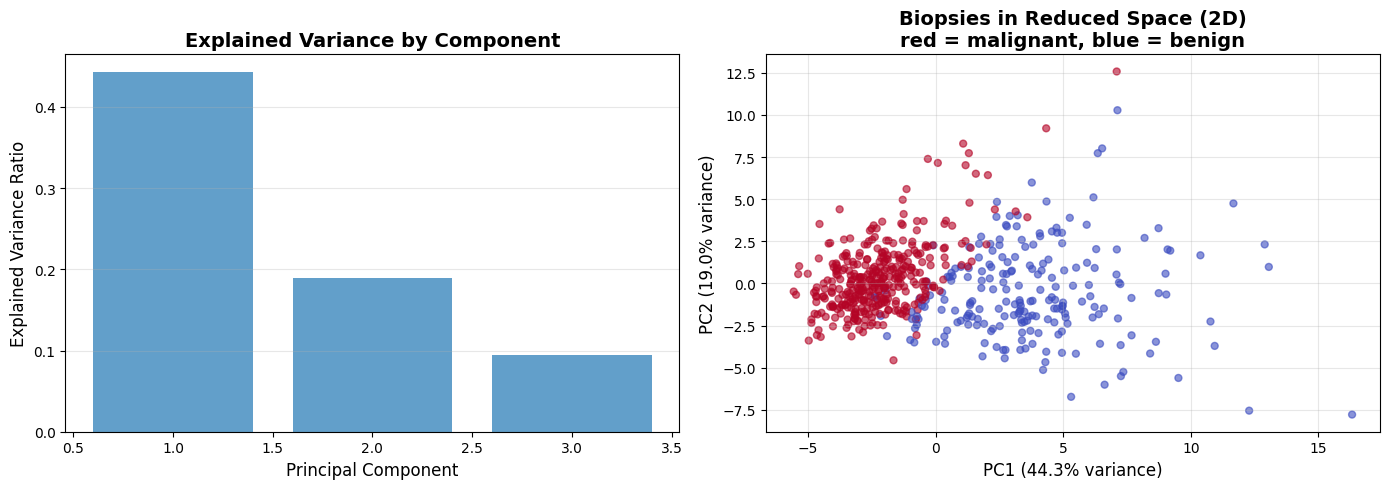


📊 Visualization:
  - Left: Variance explained by each component
  - Right: Biopsies projected to 2D using the first 2 components
  - PCA never saw the diagnosis, yet the two groups largely separate


In [4]:
# Visualize PCA results
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Explained variance
    axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7)
    axes[0].set_xlabel('Principal Component', fontsize=12)
    axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
    axes[0].set_title('Explained Variance by Component', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Data in reduced space
    axes[1].scatter(data_reduced[:, 0], data_reduced[:, 1], c=labels, cmap='coolwarm',
                    alpha=0.6, s=25)
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    axes[1].set_title('Biopsies in Reduced Space (2D)\nred = malignant, blue = benign',
                      fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Visualization:")
    print("  - Left: Variance explained by each component")
    print("  - Right: Biopsies projected to 2D using the first 2 components")
    print("  - PCA never saw the diagnosis, yet the two groups largely separate")
except:
    print("Visualization requires sklearn")

---

## ⚠️ Where this breaks

- **PCA maximises variance, not separability, and it got lucky here.** The components computed above separate benign
  from malignant biopsies without ever seeing a label. That is a property of *this* dataset: tumour size
  measurements happen to be both the highest-variance direction and the diagnostic one. When the
  discriminative signal sits in a low-variance direction, PCA will throw it away first. The supervised
  alternative that optimises separation directly is Linear Discriminant Analysis — and if you have labels,
  there is no reason not to use them.
- **Variance kept and accuracy do not move together — the table above proves it.** Ten components keep
  95.2% of the variance and score **0.9807**, better than all thirty raw features (**0.9789**). Two
  components keep only 63.2% and score **0.9578** — *better* than three components at 72.6% (**0.9491**).
  Nothing about "explained variance" predicts that ordering, because variance is a property of the data
  and accuracy is a property of the task. When you have labels, choose k by the second column.
- **72.6% for three components is the real price.** The printed note is worth re-reading: 5 of 30
  components for 80% of the variance, 10 of 30 for 95%. Compression, not a free lunch.
- **The components depend on who is in the sample.** PCA directions are eigenvectors of *your sample's*
  covariance matrix. Add a group of patients whose measurements differ systematically and the axes rotate,
  so "PC1" is not a fixed quantity you can compare across studies. This is why a PCA plot is a description
  of a dataset and not a measurement of the world — a caution that applies as much to Novembre's map as to
  the biopsies here.
- **Standardize first, and fit inside the split.** Unit 1, notebook 03 shows what unstandardized PCA does:
  the largest-numbered feature becomes PC1 and the variance-explained figure becomes meaningless. And
  fitting PCA on all 569 rows before evaluating, as this notebook does for demonstration, leaks test
  information into the components.


---

## 💬 Discuss

1. Novembre's PCA reproduced a map of Europe from genetic data alone, and the authors were careful about
   what that does and does not imply about ancestry. What is the difference between "the data contains
   geographic structure" and "this person is from there", and where could that distinction be abused?
2. PCA separated the two diagnoses without seeing them. Should that increase or decrease your confidence
   in the model you build on those components? Say what you would test.
3. A hospital asks you to report "the two most important measurements" from these 30. PC1 is a weighted
   combination of all thirty. Can you answer their question honestly with PCA? If not, what would you do
   instead, and what do you lose?


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding PCA:

1. **Dimensionality Reduction**: Can reduce data dimensions
2. **Data Compression**: Can compress data efficiently
3. **Visualization**: Can visualize high-dimensional data
4. **Next Steps**: Learn curse of dimensionality (Example 2) and feature selection (Example 3)

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand this concept.

**AFTER this notebook**: We understand WHY, HOW, and AFTER!

---

## ✅ Example Complete!

## 📚 References

1. Pearson, K. (1901). *On Lines and Planes of Closest Fit to Systems of Points in Space*. Philosophical Magazine, 2(11), 559–572.
2. Hotelling, H. (1933). *Analysis of a Complex of Statistical Variables into Principal Components*. Journal of Educational Psychology, 24, 417–441.
3. Jolliffe, I. T., & Cadima, J. (2016). *Principal Component Analysis: A Review and Recent Developments*. Philosophical Transactions of the Royal Society A, 374(2065). <https://doi.org/10.1098/rsta.2015.0202>